<a href="https://colab.research.google.com/github/Seungkyu-Han/deep_learning/blob/main/ch3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
def step_function(x: float):
  return 1 if x > 0 else 0

In [2]:
import numpy as np
x = np.array([-1.0, 0.0, 1.0])
x

array([-1.,  0.,  1.])

In [3]:
y = x > 0
y

array([False, False,  True])

In [4]:
y = y.astype(int)
y

array([0, 0, 1])

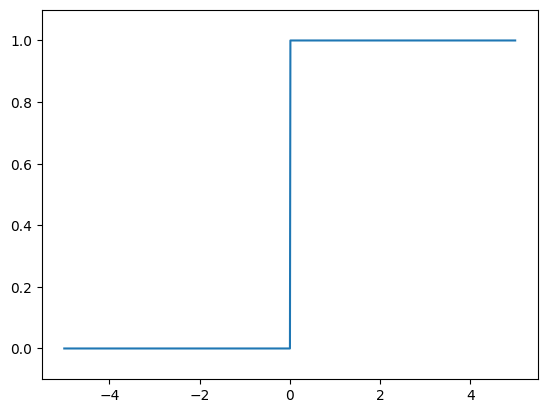

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def step_function(x):
  return np.array(x > 0, dtype=int)

x = np.arange(-5.0, 5.0, 0.01)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

In [6]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

In [7]:
x = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
sigmoid(x)

array([0.11920292, 0.26894142, 0.5       , 0.73105858, 0.88079708])

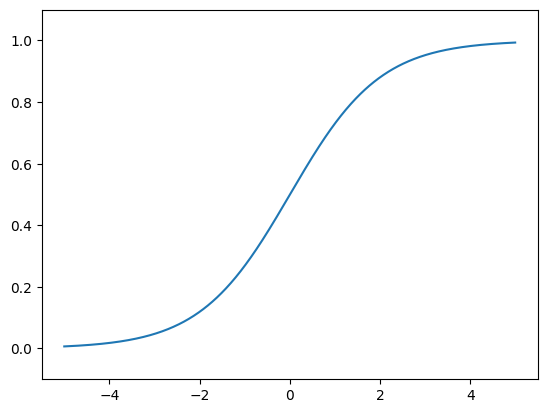

In [8]:
x = np.arange(-5.0, 5.0, 0.01)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

In [9]:
A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.array([[1, 2], [3, 4], [5, 6]])

np.dot(A, B)

array([[22, 28],
       [49, 64]])

In [10]:
X = np.array([1, 2])
W = np.array([[1, 3, 5], [2, 4, 6]])

Y = np.dot(X, W)
Y

array([ 5, 11, 17])

In [11]:
X = np.array([1.0, 0.5])
W1 = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])

A1 = np.dot(X, W1) + B1
A1

array([0.3, 0.7, 1.1])

In [12]:
Z1 = sigmoid(A1)

Z1

array([0.57444252, 0.66818777, 0.75026011])

In [13]:
def init_node()-> dict[str, np.ndarray]:
  nodes: dict[str, np.ndarray] = {}
  # 0층 -> 1층 가중치
  nodes['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
  # 0층 편향
  nodes['b1'] = np.array([0.1, 0.2, 0.3])
  # 1층 -> 2층 가중치
  nodes['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
  # 1층 편향
  nodes['b2'] = np.array([0.1, 0.2])
  # 2층 -> 3층 가중치
  nodes['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
  # 2층 편향
  nodes['b3'] = np.array([0.1, 0.2])
  return nodes


def forward(nodes: dict[str, np.ndarray], x: np.ndarray) -> np.ndarray:
  W1, W2, W3 = nodes['W1'], nodes['W2'], nodes['W3']
  b1, b2, b3 = nodes['b1'], nodes['b2'], nodes['b3']

  # 1층
  a1 = np.dot(x, W1) + b1
  z1 = sigmoid(a1)

  # 2층
  a2 = np.dot(z1, W2) + b2
  z2 = sigmoid(a2)

  # 3층(출력층)
  a3 = np.dot(z2, W3) + b3
  y = a3

  return y

nodes = init_node()
x = np.array([1.0, 2.0])
y = forward(nodes, x)
y

array([0.32403126, 0.71230655])

In [14]:
a = np.array([0.3, 2.9, 4.0])

exp_a = np.exp(a)
print(exp_a)

sum_exp_a = np.sum(exp_a)
print(sum_exp_a)

y = exp_a / sum_exp_a
print(y)


[ 1.34985881 18.17414537 54.59815003]
74.1221542101633
[0.01821127 0.24519181 0.73659691]


In [15]:
def softmax(a):
  exp_a = np.exp(a)
  sum_exp_a = np.sum(exp_a)
  y = exp_a / sum_exp_a

  return y

In [16]:
np.exp(5000)

/tmp/ipykernel_2913/2800439034.py:1: RuntimeWarning: overflow encountered in exp
  np.exp(5000)


np.float64(inf)

In [17]:
a = np.array([101, 100, 99])
softmax(a)

array([0.66524096, 0.24472847, 0.09003057])

In [18]:
max_value = np.max(a)

softmax(a - max_value)

array([0.66524096, 0.24472847, 0.09003057])

In [19]:
a = np.array([1010, 1000, 990])
softmax(a)

/tmp/ipykernel_2913/84051879.py:2: RuntimeWarning: overflow encountered in exp
  exp_a = np.exp(a)
/tmp/ipykernel_2913/84051879.py:4: RuntimeWarning: invalid value encountered in divide
  y = exp_a / sum_exp_a


array([nan, nan, nan])

In [20]:
max_value = np.max(a)

softmax(a - max_value)

array([9.99954600e-01, 4.53978686e-05, 2.06106005e-09])

In [25]:
# coding: utf-8
try:
    import urllib.request
except ImportError:
    raise ImportError('You should use Python 3.x')
import os.path
import gzip
import pickle
import os
import numpy as np


url_base = 'https://ossci-datasets.s3.amazonaws.com/mnist/'
key_file = {
    'train_img':'train-images-idx3-ubyte.gz',
    'train_label':'train-labels-idx1-ubyte.gz',
    'test_img':'t10k-images-idx3-ubyte.gz',
    'test_label':'t10k-labels-idx1-ubyte.gz'
}

dataset_dir = os.getcwd()
save_file = os.path.join(dataset_dir, "mnist.pkl")

train_num = 60000
test_num = 10000
img_dim = (1, 28, 28)
img_size = 784


def _download(file_name):
    file_path = dataset_dir + "/" + file_name

    if os.path.exists(file_path):
        return

    print("Downloading " + file_name + " ... ")
    urllib.request.urlretrieve(url_base + file_name, file_path)
    print("Done")

def download_mnist():
    for v in key_file.values():
       _download(v)

def _load_label(file_name):
    file_path = dataset_dir + "/" + file_name

    print("Converting " + file_name + " to NumPy Array ...")
    with gzip.open(file_path, 'rb') as f:
            labels = np.frombuffer(f.read(), np.uint8, offset=8)
    print("Done")

    return labels

def _load_img(file_name):
    file_path = dataset_dir + "/" + file_name

    print("Converting " + file_name + " to NumPy Array ...")
    with gzip.open(file_path, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=16)
    data = data.reshape(-1, img_size)
    print("Done")

    return data

def _convert_numpy():
    dataset = {}
    dataset['train_img'] =  _load_img(key_file['train_img'])
    dataset['train_label'] = _load_label(key_file['train_label'])
    dataset['test_img'] = _load_img(key_file['test_img'])
    dataset['test_label'] = _load_label(key_file['test_label'])

    return dataset

def init_mnist():
    download_mnist()
    dataset = _convert_numpy()
    print("Creating pickle file ...")
    with open(save_file, 'wb') as f:
        pickle.dump(dataset, f, -1)
    print("Done!")

def _change_one_hot_label(X):
    T = np.zeros((X.size, 10))
    for idx, row in enumerate(T):
        row[X[idx]] = 1

    return T


def load_mnist(normalize=True, flatten=True, one_hot_label=False):
    """MNIST 데이터셋 읽기

    Parameters
    ----------
    normalize : 이미지의 픽셀 값을 0.0~1.0 사이의 값으로 정규화할지 정한다.
    one_hot_label :
        one_hot_label이 True면、레이블을 원-핫(one-hot) 배열로 돌려준다.
        one-hot 배열은 예를 들어 [0,0,1,0,0,0,0,0,0,0]처럼 한 원소만 1인 배열이다.
    flatten : 입력 이미지를 1차원 배열로 만들지를 정한다.

    Returns
    -------
    (훈련 이미지, 훈련 레이블), (시험 이미지, 시험 레이블)
    """
    if not os.path.exists(save_file):
        init_mnist()

    with open(save_file, 'rb') as f:
        dataset = pickle.load(f)

    if normalize:
        for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].astype(np.float32)
            dataset[key] /= 255.0

    if one_hot_label:
        dataset['train_label'] = _change_one_hot_label(dataset['train_label'])
        dataset['test_label'] = _change_one_hot_label(dataset['test_label'])

    if not flatten:
         for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].reshape(-1, 1, 28, 28)

    return (dataset['train_img'], dataset['train_label']), (dataset['test_img'], dataset['test_label'])


In [26]:
a = load_mnist()

In [27]:
a

((array([[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
  array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)),
 (array([[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
  array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)))

In [29]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True)

In [30]:
print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


5
(784,)
(28, 28)


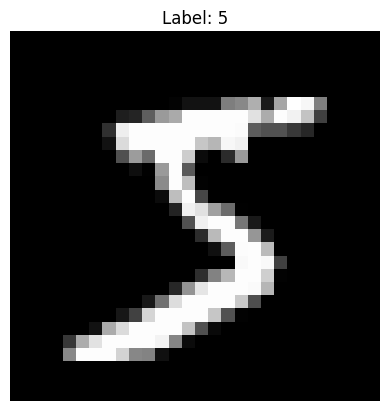

In [32]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)

import numpy as np
import matplotlib.pyplot as plt

(x_train, t_train), (x_test, t_test) = load_mnist(
    flatten=True,
    normalize=False
)

img = x_train[0]
label = t_train[0]

print(label)          # 5
print(img.shape)      # (784,)

img = img.reshape(28, 28)

print(img.shape)      # (28, 28)

plt.imshow(img, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()